## Metrics Evaluation Lab

Throughout your early career as a Data Scientist you've spent most your time cleaning data, but now you are starting to build models and have come to realize the most important part about understanding any machine learning model (or any model, really) is understanding its weakness and vulnerabilities.

In doing so you've decided to practice on a dataset about mushrooms, because after all if you don't know how to evaluate a model thoroughly you'll be in real **truffle** (ha...ha) and use a approach to which you are familiar, kNN.

Below we build an initial **Decision Tree** model on the mushroom dataset to get you started. Think of the Decision Tree as your field guide – splitting mushrooms into categories one feature at a time. No need to *cap* your curiosity, let’s dig into the *mycelium* of model evaluation! 🍄

### Part 1

Using the [mushroom dataset](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip), Define a question that can be answered using classification.

- [Mushroom Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

**Starter question (used in this notebook):** *Can we predict whether a mushroom is poisonous or edible based on its physical characteristics?* After all, mis-classifying a death-cap as dinner would be a *grave* mistake. 💀🍄

### Part 2

Build a model, make sure to calculate the prevalence to provide a reference for some of these measures and to properly clean and prepare the data ahead of building the model. Evaluate the model using the metrics discussed in class (Accuracy, TPR, FPR, F1, Cross Entropy, and ROC/AUC). What do these metrics tell you about the model?

### Part 3

In consideration of all the metrics you just used are there a few that seem more important given the question you are asking? Why?

### Part 4

Consider where classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case.

### Bonus

Use a metric we did not discuss in class (reference the [sklearn model metrics documentation](https://scikit-learn.org/stable/modules/model_evaluation.html)). Once you have the output, summarize in a sentence or two what the metric is and what it means in the context of your question.

### Keys to Success 🔑🍄

- Thoughtfully creating a question that aligns with the dataset and classification
- Using the evaluation metrics correctly – we are focusing on classification not regression
- Evaluation is not about the metrics per se, but what they mean; speaking through your question in light of the evaluation metrics is the primary objective of this lab. Think of yourself as a "model detective" that works to leave no stone unturned!
- Remember, be patient and double check your code or you might find yourself in real **shiitake** :)

Now let’s get cooking – *portobello* your sleeves and get to work! 🍄👨‍🍳

---
## Initial Decision Tree Model – Starter Code

The code below walks you through an initial Decision Tree classifier on the mushroom dataset. Use it as a *spore*-ing board (sorry, not sorry) to complete the lab.

### Step 1 – Imports

In [1]:
# Imports – the secret sauce (or should we say, secret spores?) 🍄
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

### Step 2 – Load the Mushroom Dataset

We load the mushroom dataset directly. The target column is `type` (poisonous **p** vs edible **e**). One wrong bite and you’ll be pushing up daisies – so let’s make sure our model doesn’t *morel*-ly wound us. 🍄

For the full lab you may want to use the secondary mushroom dataset from UCI:
- [Download](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip)
- [Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

In [2]:
# Load the mushroom dataset – because regular datasets are too mainstream 🍄
mushroom_url = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/mushrooms.csv"
)

mushroom_data = pd.read_csv(mushroom_url)

print(f'Dataset shape: {mushroom_data.shape}')
# That is a LOT of mushrooms – hope we brought a big enough basket! 🍄🧺
mushroom_data.head()

Dataset shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Step 3 – Explore the Data

Before we *cap* off the exploration, let’s peek under the mushroom’s hood. 🍄🔍

In [3]:
# What's inside this fungal feast? Let's find out 🍄
print(mushroom_data.dtypes)
print('---')
print(mushroom_data.describe())

type                        str
cap_shape                   str
cap_surface                 str
cap_color                   str
bruises                     str
odor                        str
gill_attachment             str
gill_spacing                str
gill_size                   str
gill_color                  str
stalk_shape                 str
stalk_root                  str
stalk_surface_above_ring    str
stalk_surface_below_ring    str
stalk_color_above_ring      str
stalk_color_below_ring      str
veil_type                   str
veil_color                  str
ring_number                 str
ring_type                   str
spore_print_color           str
population                  str
habitat                     str
dtype: object
---
        type cap_shape cap_surface cap_color bruises  odor gill_attachment  \
count   8124      8124        8124      8124    8124  8124            8124   
unique     2         6           4        10       2     9               2   
top        e

In [4]:
# Check for missing values – we don't want any rotten spores hiding in our data 🍄
print(mushroom_data.isnull().sum())

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64


### Step 4 – Clean & Prepare the Data

Time to clean up – think of it as washing your mushrooms before cooking. Nobody wants gritty data in their model stew. 🍄🧹

In [5]:
# Drop rows with missing values – keep only the freshest fungi 🍄
mushroom_data = mushroom_data.dropna()
print(f'Rows after cleaning: {len(mushroom_data)}')

Rows after cleaning: 8124


In [6]:
# Separate features (X) and target (y)
# Our target is 'type' – predicting poisonous (p) vs edible (e)
# Getting this wrong could be a fatal mis-steak... er, mis-shroom 🍄💀
y = mushroom_data['type']
X = mushroom_data.drop('type', axis=1).copy()

In [7]:
# Calculate prevalence – how common is each class?
# This tells us what accuracy we'd get if we just guessed the majority class every time.
# If our model can't beat the prevalence, it's about as useful as a chocolate teapot...
# or a poisonous mushroom at a dinner party 🍄
prevalence = y.value_counts(normalize=True)
print('Class prevalence (baseline):')
print(prevalence)
print(f'\nMajority class baseline accuracy: {prevalence.max():.4f}')

Class prevalence (baseline):
type
e    0.517971
p    0.482029
Name: proportion, dtype: float64

Majority class baseline accuracy: 0.5180


In [8]:
# Encode categorical features – Decision Trees can handle categories
# but sklearn needs everything numeric. Time to put on our encoder caps! 🎩🍄
le_dict = {}  # store encoders so we can decode later if needed

for col in X.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# Encode the target variable too
le_target = LabelEncoder()
y = le_target.fit_transform(y)  # e=0, p=1
print('Target classes:', le_target.classes_)  # just to confirm the mapping

Target classes: ['e' 'p']


### Step 5 – Partition the Data

We split our fungi into training, tuning, and test sets. Think of it as sorting mushrooms into three baskets: one to learn from, one to adjust your recipe, and one to serve to the judges. 🍄🧺

In [9]:
# 70 / 15 / 15 split – train / tune / test
# Stratify keeps the same ratio of edible:poisonous in every basket 🍄
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.70, stratify=y, random_state=42
)

X_tune, X_test, y_tune, y_test = train_test_split(
    X_temp, y_temp, train_size=0.50, stratify=y_temp, random_state=42
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Tuning set:    {X_tune.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
# That's a lot of mushrooms! Hope nobody's allergic... 🍄

Training set:  5686 samples
Tuning set:    1219 samples
Test set:      1219 samples


### Step 6 – Build the Decision Tree Model 🌳🍄

Decision Trees work by asking a series of yes/no questions about the features, branching like the mycelium network under a forest floor. Each split gets us closer to the answer: **eat it or yeet it?**

In [10]:
# Plant our Decision Tree – let's see if it can tell a chanterelle from a death cap 🍄🌳
dt_model = DecisionTreeClassifier(
    max_depth=5,          # keep the tree from growing wild like forest fungi
    random_state=42,
    criterion='gini'      # Gini impurity – not a mushroom variety, we promise
)

dt_model.fit(X_train, y_train)
print(f'Training accuracy: {dt_model.score(X_train, y_train):.4f}')
print(f'Tuning accuracy:   {dt_model.score(X_tune, y_tune):.4f}')

Training accuracy: 0.9773
Tuning accuracy:   0.9869


/tmp/ipykernel_14803/2616182962.py:12: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14803/2616182962.py:12: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/week_10_eval/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspaces/week_10_eval/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


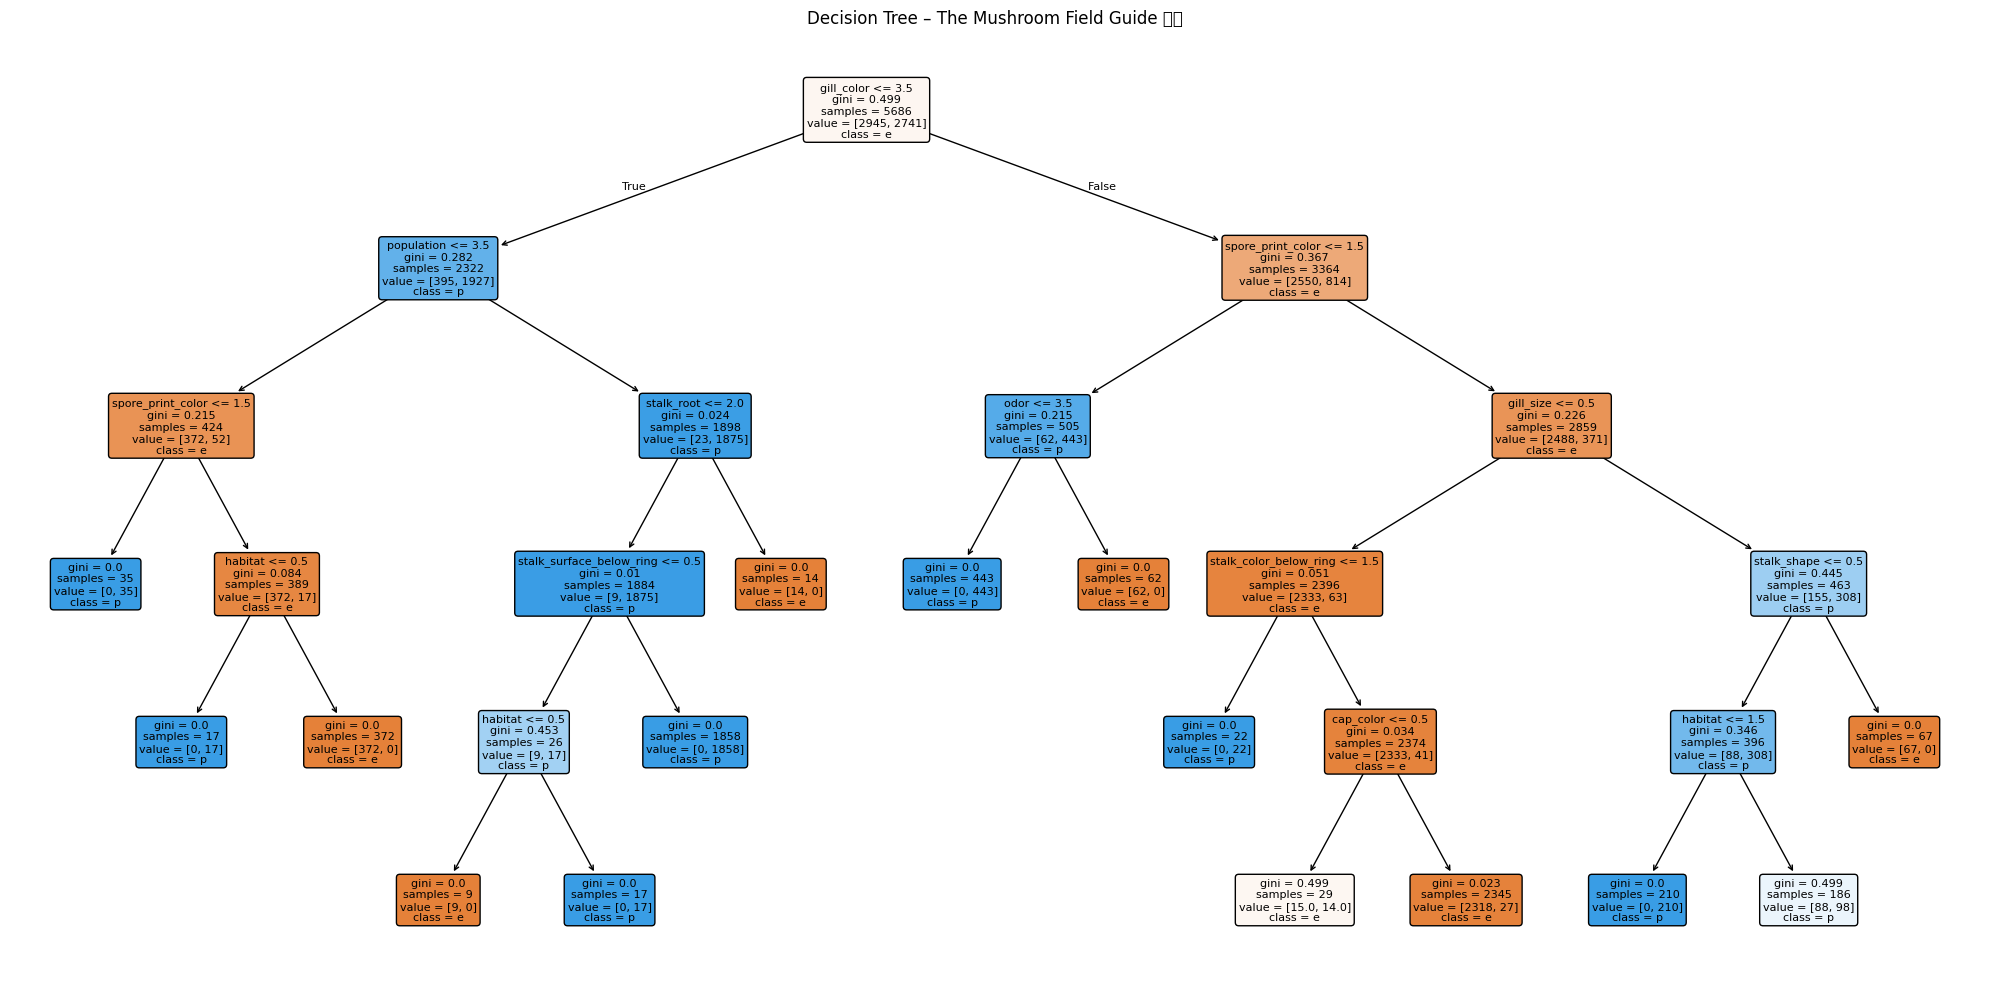

In [11]:
# Let's visualize the tree – every branch is a decision, every leaf is a verdict 🍄🌿
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=le_target.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree – The Mushroom Field Guide 🍄🌳')
plt.tight_layout()
plt.show()

---
## Evaluation Metrics

Time to find out how well our tree knows its fungi. If we’re wrong about a poisonous mushroom, that’s a *cap*-ital offense! 🍄📊

In [12]:
# Generate predictions and predicted probabilities on the tuning set
# Think of probabilities as how confident our tree is – "I'm 95% sure that's a shiitake" 🍄
dt_pred = dt_model.predict(X_tune)
dt_prob = dt_model.predict_proba(X_tune)

# Bundle everything into a tidy DataFrame – like a nice mushroom risotto 🍄🍚
results = pd.DataFrame({
    'target': y_tune,
    'pred': dt_pred,
    'prob_edible': dt_prob[:, 0],
    'prob_poisonous': dt_prob[:, 1]
})
results.head()

,target,pred,prob_edible,prob_poisonous
0,1,1,0.000000,1.000000
1,1,1,0.000000,1.000000
2,0,0,0.988486,0.011514
3,1,1,0.000000,1.000000
4,1,1,0.000000,1.000000


#### Confusion Matrix

The confusion matrix shows us where our model is getting confused – kind of like trying to tell button mushrooms and baby bellas apart at the grocery store. 🍄🛒

Confusion Matrix:
[[618  13]
 [  3 585]]


/workspaces/week_10_eval/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


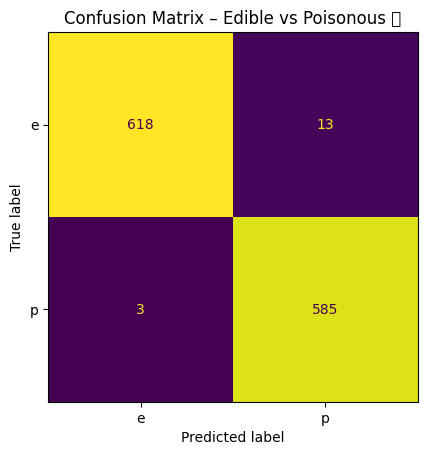

In [13]:
# Confusion Matrix – the moment of truffle! 🍄
cm = metrics.confusion_matrix(results.target, results.pred)
print('Confusion Matrix:')
print(cm)

disp = metrics.ConfusionMatrixDisplay.from_predictions(
    results.target, results.pred,
    display_labels=le_target.classes_,
    colorbar=False
)
plt.title('Confusion Matrix – Edible vs Poisonous 🍄')
plt.show()

#### Accuracy

In [14]:
# Accuracy – what proportion did we get right overall?
# But beware: accuracy alone can be misleading, like a pretty but deadly Amanita 🍄☠️
accuracy = metrics.accuracy_score(results.target, results.pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9869


#### True Positive Rate (Sensitivity / Recall) & False Positive Rate

In [15]:
# TPR (True Positive Rate) = Recall = Sensitivity
# Of all the actually poisonous mushrooms, how many did we correctly flag? 🍄🚩
# FPR (False Positive Rate) = how many safe mushrooms did we wrongly accuse?
tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)  # Sensitivity / Recall
fpr = fp / (fp + tn)

print(f'True Positive Rate  (TPR / Recall): {tpr:.4f}')
print(f'False Positive Rate (FPR):          {fpr:.4f}')
# A high TPR means we're catching the dangerous ones – nobody wants a false negative
# when the stakes are your stomach (or your life) 🍄💀

True Positive Rate  (TPR / Recall): 0.9949
False Positive Rate (FPR):          0.0206


#### F1 Score

In [16]:
# F1 Score – the harmonic mean of precision and recall
# It balances both types of mistakes, like a perfectly balanced mushroom risotto 🍄🍚
f1 = metrics.f1_score(results.target, results.pred)
print(f'F1 Score: {f1:.4f}')

F1 Score: 0.9865


#### Classification Report

In [17]:
# Full classification report – the tasting menu of evaluation metrics 🍄🍽️
print(metrics.classification_report(
    results.target, results.pred,
    target_names=le_target.classes_
))

              precision    recall  f1-score   support

           e       1.00      0.98      0.99       631
           p       0.98      0.99      0.99       588

    accuracy                           0.99      1219
   macro avg       0.99      0.99      0.99      1219
weighted avg       0.99      0.99      0.99      1219



#### Cross-Entropy (Log Loss)

Cross-entropy measures how well our predicted probabilities match reality. Lower is better – like the amount of dirt you want on your mushrooms. 🍄

In [18]:
# Cross-Entropy / Log Loss – punishes confident wrong answers harshly
# Saying "I'm 99% sure this is edible" when it's actually deadly? Big penalty. 🍄💥
log_loss = metrics.log_loss(results.target, dt_prob)
print(f'Cross-Entropy (Log Loss): {log_loss:.4f}')
# Close to 0 = good, over 1 = your model is in deep shiitake 🍄

Cross-Entropy (Log Loss): 0.0372


#### ROC Curve & AUC

The ROC curve plots TPR vs FPR at every threshold. AUC (Area Under the Curve) summarises it in one number – 1.0 is perfect, 0.5 is a coin flip. Let’s hope our model does better than flipping a mushroom in the air! 🍄🪙

/workspaces/week_10_eval/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127812 (\N{MUSHROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


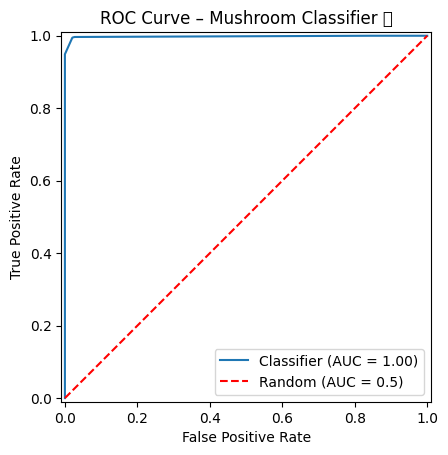

AUC Score: 0.9980


In [19]:
# ROC Curve – the ultimate mushroom taste test 🍄📈
metrics.RocCurveDisplay.from_predictions(
    results.target, results.prob_poisonous
)
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
plt.title('ROC Curve – Mushroom Classifier 🍄')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

auc_score = metrics.roc_auc_score(results.target, results.prob_poisonous)
print(f'AUC Score: {auc_score:.4f}')
# An AUC near 1.0 means our tree really knows its mushrooms! 🍄🏆

---
## What’s Next?

You now have a working Decision Tree baseline. From here:

1. **Answer Part 1** – refine or create your own classification question.
2. **Complete Part 2** – explore the metrics above and explain what they tell you.
3. **Tackle Parts 3 & 4** – think critically about which metrics matter most and where errors occur.
4. **Attempt the Bonus** – pick a metric we haven’t covered (e.g., Matthews Correlation Coefficient, Precision-Recall AUC, Cohen’s Kappa) and discuss it.

Remember: the goal isn’t just to compute numbers – it’s to *understand* what your model is doing right, where it’s falling short, and why. Don’t be a *fun-gi* who ignores the details! 🍄🎉

Good luck, and may your mushrooms always be correctly classified! 🍄✅